# Phase 6: retraining the head

Phase 5 blamed two of the model's problems on training choices: inflated probabilities on the positive
weighting in the loss, and a synovitis score that is really an effusion score on the "unsure" soft labels
(0.35-0.45) the labelling model used when a report said nothing about synovitis. This notebook tests both
claims by changing only those choices and retraining.

Only the attention head is retrained (280 k parameters). The backbone stays frozen: its window features for
all 4,407 studies were computed once on Kaggle (`kaggle/train_feats`), and each head then trains in about 11
seconds on a laptop (`scripts/train_heads.py`). Only aggregate numbers are shown.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import evaluation as ev
import explain as ex
import head_training as ht
import plot_style as ps
import raptor_core as rc

ps.apply()
H = ROOT / "outputs/local/heads"
FIG = ROOT / "outputs/figures"; FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.precision", 3)
ix = rc.LAB.index

runs = pd.read_csv(H / "runs.csv")
Y = np.load(H / "gold_labels.npy")
checkpoint_logits = np.load(H / "checkpoint_gold_logits.npy")

## 1. Are the new features the old features?

The 58 gold studies were encoded again in the feature job. Scoring them with the checkpoint's own head should
reproduce Phase 0.

In [2]:
feats = np.concatenate([np.load(ROOT / f"outputs/kaggle/train_feats/feats_shard{k}.npy") for k in (0, 1)])
ids = np.concatenate([np.load(ROOT / f"outputs/kaggle/train_feats/ids_shard{k}.npy") for k in (0, 1)]).astype(str)
gold = pd.read_csv(ROOT / "outputs/kaggle/gold_run/gold_labels.csv")
row = {s: i for i, s in enumerate(ids)}
old = np.load(ROOT / "outputs/kaggle/gold_run/feats_A_imagenet.npy").astype(np.float32)
new = feats[[row[s] for s in gold.StudyInstanceUID.astype(str)]].astype(np.float32)
print(f"{len(ids)} studies encoded | mean |feature difference| on gold {np.abs(new - old).mean():.4f} "
      f"(features average {np.abs(old).mean():.2f})")
print(f"checkpoint head on the new features: macro-AUC {rc.macro_auc(Y, checkpoint_logits)[0]:.4f} (Phase 0: 0.9171)")

4407 studies encoded | mean |feature difference| on gold 0.0011 (features average 1.51)


checkpoint head on the new features: macro-AUC 0.9170 (Phase 0: 0.9171)


The differences are half-precision jitter from a different GPU run, and the score is unchanged.

## 2. The recipes

| Recipe | Targets | Positive weighting | Unsure labels (0.3-0.5) | Starting head |
|---|---|---|---|---|
| R1 author's recipe | soft | yes | kept | fresh |
| R2 | soft | no | kept | fresh |
| R3 | soft | no | masked | fresh |
| R4 | soft | yes | masked | fresh |
| R5 | hard (0/1) | no | kept | fresh |
| R6 | soft | no | masked | the checkpoint's head |

R1-R4 form a 2 x 2 design: positive weighting on or off, crossed with unsure labels kept or masked.

Every head trains on 3,697 soft-labelled studies and keeps the epoch with the lowest validation loss on another
652, never looking at the 58 gold studies. Each recipe runs with 3 seeds; the gold scores below use the average
of the three heads' logits.

In [3]:
RECIPES = ["R1_author", "R2_no_posweight", "R3_mask_unsure", "R4_mask_unsure_posweight", "R5_hard", "R6_warm_mask_unsure"]
logits = {"checkpoint": checkpoint_logits}
for r in RECIPES:
    logits[r] = np.mean([np.load(H / f"{r}_seed{s}.npz")["gold_logits"] for s in range(3)], axis=0)

seed_spread = runs.groupby("recipe").gold_macro_auc.agg(["min", "max"])
W = ev.bootstrap_weights(len(Y), 4000, seed=2646)
base_boot = np.nanmean(ev.bootstrap_aucs(Y, checkpoint_logits, W), axis=1)


def ece(p, y, bins=10):
    idx = np.minimum((p * bins).astype(int), bins - 1)
    return sum((idx == b).mean() * abs(p[idx == b].mean() - y[idx == b].mean()) for b in range(bins) if (idx == b).any())


rows = []
for name, L in logits.items():
    macro, aucs = rc.macro_auc(Y, L)
    lo, hi = ev.percentile_ci(np.nanmean(ev.bootstrap_aucs(Y, L, W), axis=1) - base_boot)
    p = 1 / (1 + np.exp(-L))
    rows.append({"head": name, "macro-AUC": macro,
                 "seed range": "" if name == "checkpoint" else f"{seed_spread.loc[name, 'min']:.3f}-{seed_spread.loc[name, 'max']:.3f}",
                 "vs checkpoint, 95% CI": "" if name == "checkpoint" else f"{lo:+.3f} to {hi:+.3f}",
                 "synovitis AUC": aucs["Synovitis"], "ECE": ece(p.ravel(), Y.ravel()),
                 "mean p - prevalence": (p.mean(0) - Y.mean(0)).mean()})
summary = pd.DataFrame(rows).set_index("head")
summary

,macro-AUC,seed range,"vs checkpoint, 95% CI",synovitis AUC,ECE,mean p - prevalence
head,,,,,,
checkpoint,0.917,,,0.805,0.197,0.197
R1_author,0.907,0.905-0.909,-0.020 to +0.000,0.795,0.181,0.181
R2_no_posweight,0.903,0.899-0.907,-0.027 to -0.002,0.784,0.051,0.009
R3_mask_unsure,0.904,0.898-0.905,-0.027 to +0.001,0.802,0.054,0.016
R4_mask_unsure_posweight,0.906,0.903-0.905,-0.024 to +0.003,0.802,0.188,0.188
R5_hard,0.900,0.891-0.900,-0.035 to -0.002,0.796,0.070,-0.040
R6_warm_mask_unsure,0.906,0.906-0.907,-0.021 to -0.001,0.820,0.046,0.021


**No recipe beats the checkpoint's head on the gold studies.** Every retrained head lands about 0.01 lower,
including R1, which copies the author's recipe. Two explanations fit, and 58 studies cannot separate them:

- **Selection.** The checkpoint is the epoch that scored best on these 58 studies; these heads were chosen on
  held-out training studies instead. Phase 2 put that optimism at 0.002-0.010.
- **Co-training.** The checkpoint's head was trained together with the backbone, whose features adapted to it.
  A fresh head on frozen features starts from features tuned for someone else.

Differences between recipes are 0.01 or less, about the spread between seeds and below the 0.012 that Phase 2
found detectable. On macro-AUC the recipes are a tie. They differ sharply on the two things they were meant to
change.

## 3. Two training choices, two effects

Measure the effusion-synovitis entanglement on all 4,407 studies rather than 58: a correlation between two
scores needs no labels, so every study counts.

In [4]:
heads = {"checkpoint": ht.AttentionHead.from_checkpoint(rc.load_checkpoint(
    str(ROOT / "models/raptor_ft_coatnet_v10_full.pt"), "cpu")[0]).eval()}
for r in RECIPES:
    h = ht.AttentionHead(); h.load_state_dict(torch.load(H / f"{r}_seed0.pt")); heads[r] = h.eval()
tangle = {n: np.corrcoef(*ht.predict(h, feats)[:, [ix("Effusion"), ix("Synovitis")]].T)[0, 1] for n, h in heads.items()}
soft = pd.read_csv(ROOT / "data/soft_labels/labels_llm_soft.csv")
soft_r = np.corrcoef(soft["Effusion"], soft["Synovitis"])[0, 1]
summary["effusion-synovitis r (4,407 studies)"] = pd.Series(tangle)
print(f"for reference: training soft labels {soft_r:.2f}, gold labels {np.corrcoef(Y[:, ix('Effusion')], Y[:, ix('Synovitis')])[0, 1]:.2f}")
summary[["ECE", "mean p - prevalence", "effusion-synovitis r (4,407 studies)"]]

for reference: training soft labels 0.88, gold labels 0.40


,ECE,mean p - prevalence,"effusion-synovitis r (4,407 studies)"
head,,,
checkpoint,0.197,0.197,0.981
R1_author,0.181,0.181,0.971
R2_no_posweight,0.051,0.009,0.970
R3_mask_unsure,0.054,0.016,0.773
R4_mask_unsure_posweight,0.188,0.188,0.776
R5_hard,0.070,-0.040,0.972
R6_warm_mask_unsure,0.046,0.021,0.866


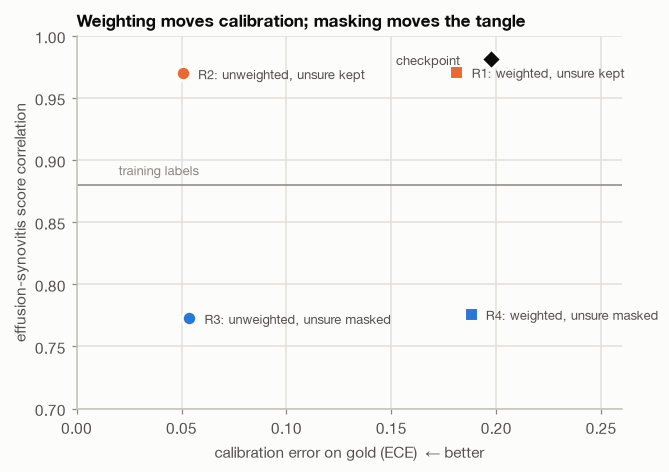

In [5]:
design = {"R1_author": ("weighted", "kept"), "R2_no_posweight": ("unweighted", "kept"),
          "R3_mask_unsure": ("unweighted", "masked"), "R4_mask_unsure_posweight": ("weighted", "masked")}
fig, ax = plt.subplots(figsize=(6.4, 4.4))
for name, (weighting, unsure) in design.items():
    x, y = summary.loc[name, "ECE"], summary.loc[name, "effusion-synovitis r (4,407 studies)"]
    ax.scatter(x, y, s=90, color=ps.BLUE if unsure == "masked" else ps.ORANGE,
               marker="o" if weighting == "unweighted" else "s", edgecolor=ps.SURFACE, linewidth=2, zorder=3)
    ax.annotate(f"{name.split('_')[0]}: {weighting}, unsure {unsure}", (x, y), xytext=(10, -4),
                textcoords="offset points", fontsize=8.5, color=ps.INK_2)
x, y = summary.loc["checkpoint", "ECE"], summary.loc["checkpoint", "effusion-synovitis r (4,407 studies)"]
ax.scatter(x, y, s=90, color=ps.INK, marker="D", edgecolor=ps.SURFACE, linewidth=2, zorder=3)
ax.annotate("checkpoint", (x, y), xytext=(-62, -4), textcoords="offset points", fontsize=8.5, color=ps.INK_2)
ax.axhline(soft_r, color=ps.MUTED, lw=1)
ax.text(0.02, soft_r + 0.008, "training labels", fontsize=8.5, color=ps.MUTED)
ax.set_xlabel("calibration error on gold (ECE)  ← better")
ax.set_ylabel("effusion-synovitis score correlation")
ax.set_xlim(0, 0.26); ax.set_ylim(0.7, 1.0)
ax.set_title("Weighting moves calibration; masking moves the tangle")
fig.savefig(FIG / "phase6_two_effects.png")
plt.show()

**Reading it.** The four heads of the 2 x 2 design land on the corners of a rectangle:

- **Positive weighting controls calibration, and nothing else.** Dropping it takes calibration error from about
  0.19 to 0.05 and the average prediction to within 0.01-0.02 of prevalence, with or without masking. Phase 5
  repaired this after the fact; here it never happens.
- **Masking unsure labels controls the entanglement, and nothing else.** Masking takes the effusion-synovitis
  correlation from 0.97 to 0.77-0.78, with or without weighting, and below the 0.88 of the training labels
  themselves. The "unsure" rows were what tied the two together. Without them the model separates synovitis
  from effusion more than its own labels do.

Each Phase 5 explanation has now survived an intervention: change the cause, and only its effect moves.

In [6]:
syn = ix("Synovitis")
pd.DataFrame({name: {"synovitis AUC, own score": ev.auc(Y[:, syn], L[:, syn]),
                     "synovitis AUC, effusion score": ev.auc(Y[:, syn], L[:, ix("Effusion")])}
              for name, L in logits.items()}).T.assign(
    **{"own minus effusion": lambda d: d.iloc[:, 0] - d.iloc[:, 1]})

,"synovitis AUC, own score","synovitis AUC, effusion score",own minus effusion
checkpoint,0.805,0.800,0.005
R1_author,0.795,0.800,-0.006
R2_no_posweight,0.784,0.784,0.000
R3_mask_unsure,0.802,0.781,0.020
R4_mask_unsure_posweight,0.802,0.795,0.007
R5_hard,0.796,0.781,0.014
R6_warm_mask_unsure,0.820,0.797,0.023


On the gold studies the synovitis score now carries a little of its own information. R3 and R6 beat the effusion
score by about 0.02, against 0.005 for the checkpoint; R4, masked but still weighted, only by 0.007. R6, which starts from the checkpoint's head and
continues with unsure labels masked, reaches the best synovitis AUC (0.820). With 27 positives, though, a
single finding's AUC is uncertain by about ±0.12 (Phase 2), so these gold numbers are suggestive only. The
4,407-study correlation above is the solid evidence.

## 4. Summary

| Question | Answer |
|---|---|
| Does removing positive weighting fix calibration at training time? | Yes: ECE 0.19 to 0.05, average prediction within 0.02 of prevalence |
| Does masking unsure labels untangle synovitis from effusion? | Yes: score correlation 0.97 to 0.77 across 4,407 studies, below the labels' own 0.88 |
| Do the two interact? | No: each moves only its own effect in the 2 x 2 design |
| Does any recipe beat the checkpoint on macro-AUC? | No: all about 0.01 lower on the 58 gold studies, consistent with the checkpoint having been selected on them |

The gold set cannot tell whether that 0.01 is real. The hidden test set can: submitting one retrained head would
settle it.